In [104]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
import sklearn.metrics as metrics
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score

df = pd.read_csv('C:/Users/luna/Desktop/FuelEfficiencyPrediction/data/auto_mpg.csv')
df.head() 

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


MPG - (miles per gallon) mức tiêu thụ nhiên liệu (số dặm xe được được trên 1 gallon nhiên liệu ) = dặm đi được / gallon nhiên liệu tiêu thụ
        1 galon (US) = khoảng 3.785 lít.
        1 galon (UK) = khoảng 4.546 lít (được gọi là "imperial gallon" trong hệ đo lường của Vương quốc Anh).
        MPG càng lớn càng tốt
Cylinders: Số xy-lanh của động cơ. ( số buồng đốt)
Displacement: Dung tích động cơ. (khối lượng không khí và nhiên liệu mà tất cả các xy-lanh của động cơ có thể chứa)
Horsepower: Mã lực. ( đo lượng công việc mà một động cơ có thể thực hiện trong một khoảng thời gian (1s) )
Weight: Trọng lượng của xe.
Acceleration: Tốc độ tăng tốc. (  thời gian tăng từ trạng thái dừng lên 60mph)
Model Year: Năm sản xuất của xe.
Origin: Xuất xứ của xe.

In [105]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [106]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


ta thấy các cột về kiểu dữ liệu đã đúng số hàng cũng đã đủ nhưng với cột horsepower đang thiếu 6 value . Ta sẽ phải xử lý 
origin (object): Đại diện cho xuất xứ của xe là dữ liệu dạng phân loại (categorical), kiểu object là phù hợp nhưng cần chuyển đổi thành dạng label encoding hoặc one-hot encoding khi xây dựng mô hình.
name (object): Đây là tên xe, cũng là dữ liệu phân loại dạng chuỗi (object). Cột này có thể không cần thiết cho mô hình vì nó không mang nhiều ý nghĩa về mặt dự đoán và có thể được loại bỏ

In [107]:
# Làm sạch dữ liệu 
duplicate_rows = df[df.duplicated()]
print(f"Số lượng dòng trùng lặp: {duplicate_rows.shape[0]}")

Số lượng dòng trùng lặp: 0


In [108]:
# 2 Sửa lỗi cấu trúc 
# xem cấu trúc
print(df.dtypes) 


mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin           object
name             object
dtype: object


Ta thấy các cột đã có type chính xác và như đã nói là cột origin cần mã hoá vì no đang là kiểu danh mục và cột name ta không cần có thể xoá cho gọn


In [109]:
# xoá cột name không cần thiết ra khỏi tập data
df = df.drop(columns=['name'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
dtypes: float64(4), int64(3), object(1)
memory usage: 25.0+ KB


In [110]:
# Mã hóa one-hot cột 'origin' ( là kỹ thuật feature tranformation)
df = pd.get_dummies(df, columns=['origin'])
df = df.astype({col: 'int' for col in df.columns if 'origin_' in col})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   mpg            398 non-null    float64
 1   cylinders      398 non-null    int64  
 2   displacement   398 non-null    float64
 3   horsepower     392 non-null    float64
 4   weight         398 non-null    int64  
 5   acceleration   398 non-null    float64
 6   model_year     398 non-null    int64  
 7   origin_europe  398 non-null    int64  
 8   origin_japan   398 non-null    int64  
 9   origin_usa     398 non-null    int64  
dtypes: float64(4), int64(6)
memory usage: 31.2 KB


In [111]:
# Kiểm tra tất cả các cột trong DataFrame
for col in df.columns:
    non_numeric_values = df[~df[col].apply(lambda x: isinstance(x, (int, float)))]
    if not non_numeric_values.empty:
        print(f"Giá trị không phải là số trong cột {col}:")
        print(non_numeric_values)
    else:
        print(f"Không có giá trị không phải là số trong cột {col}:")


Không có giá trị không phải là số trong cột mpg:
Không có giá trị không phải là số trong cột cylinders:
Không có giá trị không phải là số trong cột displacement:
Không có giá trị không phải là số trong cột horsepower:
Không có giá trị không phải là số trong cột weight:
Không có giá trị không phải là số trong cột acceleration:
Không có giá trị không phải là số trong cột model_year:
Không có giá trị không phải là số trong cột origin_europe:
Không có giá trị không phải là số trong cột origin_japan:
Không có giá trị không phải là số trong cột origin_usa:


Ta nhận thấy các cột với giá trị đã hợp lệ rồi ta chuyển sang bước tiếp theo của tiền xử lý data là xử lý các giá trị bị thiếu

In [112]:
# 3 Xử lý các giá trị bị thiếu
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

horsepower    6
dtype: int64


Như đã nói ở trên cũng như chạy lệnh vừa rồi ta thấy cột này thiếu 6 value , có thể điền trung bình , xoá ...

In [113]:
# Xóa các dòng có giá trị thiếu trong cột 'horsepower' bởi vì cột này mean 46 mà max tận 230 mà lấy mean điền vào thì không nên
df = df.dropna(subset=['horsepower'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   mpg            392 non-null    float64
 1   cylinders      392 non-null    int64  
 2   displacement   392 non-null    float64
 3   horsepower     392 non-null    float64
 4   weight         392 non-null    int64  
 5   acceleration   392 non-null    float64
 6   model_year     392 non-null    int64  
 7   origin_europe  392 non-null    int64  
 8   origin_japan   392 non-null    int64  
 9   origin_usa     392 non-null    int64  
dtypes: float64(4), int64(6)
memory usage: 33.7 KB


Ta đã xử lý song giá trị thiếu bước tiếp của tiền xử lý dữ liệu là loại bỏ giá trị ngoại lệ

In [114]:
# 4 Xử lý ngoại lai
def checkNgoaiLai(df, columns, threshold=3):
    mask = np.ones(len(df), dtype=bool)
    for col in columns:
        z_scores = np.abs(stats.zscore(df[col]))
        outliers = df[z_scores > threshold]
        print(f"Giá trị ngoại lai trong cột {col}:")
        print(outliers)
        
        mask = mask & (z_scores <= threshold)
    
    return df[mask]

columns = ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year"]

df_cleaned = checkNgoaiLai(df, columns)

print("\nDataFrame sau khi xóa ngoại lai:")
print(df_cleaned)


Giá trị ngoại lai trong cột mpg:
Empty DataFrame
Columns: [mpg, cylinders, displacement, horsepower, weight, acceleration, model_year, origin_europe, origin_japan, origin_usa]
Index: []
Giá trị ngoại lai trong cột cylinders:
Empty DataFrame
Columns: [mpg, cylinders, displacement, horsepower, weight, acceleration, model_year, origin_europe, origin_japan, origin_usa]
Index: []
Giá trị ngoại lai trong cột displacement:
Empty DataFrame
Columns: [mpg, cylinders, displacement, horsepower, weight, acceleration, model_year, origin_europe, origin_japan, origin_usa]
Index: []
Giá trị ngoại lai trong cột horsepower:
      mpg  cylinders  displacement  horsepower  weight  acceleration  \
6    14.0          8         454.0       220.0    4354           9.0   
8    14.0          8         455.0       225.0    4425          10.0   
13   14.0          8         455.0       225.0    3086          10.0   
95   12.0          8         455.0       225.0    4951          11.0   
116  16.0          8       

Từ kết quả ta thấy rằng không có giá trị ngoại lai nào trong các cột mpg, cylinders, và displacement, nhưng có một số giá trị ngoại lai trong cột horsepower. Ta cần tiếp tực xử lý

In [115]:
# Lọc ra các giá trị ngoại lai trong cột horsepower
outlier_indices = df[df['horsepower'] > 200].index  
df_cleaned = df.drop(outlier_indices)
df = df_cleaned
print("\nDataFrame sau khi loại bỏ giá trị ngoại lai trong cột horsepower:")
print(df_cleaned)


DataFrame sau khi loại bỏ giá trị ngoại lai trong cột horsepower:
      mpg  cylinders  displacement  horsepower  weight  acceleration  \
0    18.0          8         307.0       130.0    3504          12.0   
1    15.0          8         350.0       165.0    3693          11.5   
2    18.0          8         318.0       150.0    3436          11.0   
3    16.0          8         304.0       150.0    3433          12.0   
4    17.0          8         302.0       140.0    3449          10.5   
..    ...        ...           ...         ...     ...           ...   
393  27.0          4         140.0        86.0    2790          15.6   
394  44.0          4          97.0        52.0    2130          24.6   
395  32.0          4         135.0        84.0    2295          11.6   
396  28.0          4         120.0        79.0    2625          18.6   
397  31.0          4         119.0        82.0    2720          19.4   

     model_year  origin_europe  origin_japan  origin_usa  
0        

In [116]:
# thêm đặc trưng
df['hp_to_weight'] = df['horsepower'] / df['weight']
df['engine_size_per_cylinder'] = df['displacement'] / df['cylinders']
df['weight_per_cylinder'] = df['weight'] / df['cylinders']
current_year = 124
df['car_age'] = current_year - df['model_year']
# xóa đặc trưng cũ
df = df.drop(columns=['horsepower', 'weight','displacement','cylinders','model_year'])
print(df.head())


    mpg  acceleration  origin_europe  origin_japan  origin_usa  hp_to_weight  \
0  18.0          12.0              0             0           1      0.037100   
1  15.0          11.5              0             0           1      0.044679   
2  18.0          11.0              0             0           1      0.043655   
3  16.0          12.0              0             0           1      0.043694   
4  17.0          10.5              0             0           1      0.040591   

   engine_size_per_cylinder  weight_per_cylinder  car_age  
0                    38.375              438.000       54  
1                    43.750              461.625       54  
2                    39.750              429.500       54  
3                    38.000              429.125       54  
4                    37.750              431.125       54  


In [117]:
independent_vars = df[['acceleration', 'hp_to_weight', 'engine_size_per_cylinder', 'weight_per_cylinder', 'car_age']]
independent_vars = sm.add_constant(independent_vars)
vif_data = pd.DataFrame()
vif_data['Variable'] = independent_vars.columns
vif_data['VIF'] = [variance_inflation_factor(independent_vars.values, i) for i in range(independent_vars.shape[1])]
print("\nKiểm tra chỉ số VIF để xác định đa cộng tuyến:")
print(vif_data)



Kiểm tra chỉ số VIF để xác định đa cộng tuyến:
                   Variable         VIF
0                     const  580.978444
1              acceleration    2.995084
2              hp_to_weight    2.532894
3  engine_size_per_cylinder    1.534079
4       weight_per_cylinder    1.128405
5                   car_age    1.194588


Ta thấy ko có đa cộng tuyến

In [118]:
print(df.describe())

              mpg  acceleration  origin_europe  origin_japan  origin_usa  \
count  382.000000    382.000000     382.000000    382.000000  382.000000   
mean    23.721990     15.666754       0.178010      0.206806    0.615183   
std      7.709764      2.667648       0.383023      0.405547    0.487190   
min      9.000000      8.000000       0.000000      0.000000    0.000000   
25%     17.625000     14.000000       0.000000      0.000000    0.000000   
50%     23.000000     15.500000       0.000000      0.000000    1.000000   
75%     29.000000     17.200000       0.000000      0.000000    1.000000   
max     46.600000     24.800000       1.000000      1.000000    1.000000   

       hp_to_weight  engine_size_per_cylinder  weight_per_cylinder     car_age  
count    382.000000                382.000000           382.000000  382.000000  
mean       0.034415                 32.923320           553.771924   47.892670  
std        0.005258                  8.191410            82.174380    3.

ta nhận biến weight per_cylinder giá trị khá rộng ta đưa về normal scaler

In [119]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df[['engine_size_per_cylinder', 'weight_per_cylinder', 'car_age']] = scaler.fit_transform(
    df[['engine_size_per_cylinder', 'weight_per_cylinder', 'car_age']]
)
print(df)

      mpg  acceleration  origin_europe  origin_japan  origin_usa  \
0    18.0          12.0              0             0           1   
1    15.0          11.5              0             0           1   
2    18.0          11.0              0             0           1   
3    16.0          12.0              0             0           1   
4    17.0          10.5              0             0           1   
..    ...           ...            ...           ...         ...   
393  27.0          15.6              0             0           1   
394  44.0          24.6              1             0           0   
395  32.0          11.6              0             0           1   
396  28.0          18.6              0             0           1   
397  31.0          19.4              0             0           1   

     hp_to_weight  engine_size_per_cylinder  weight_per_cylinder  car_age  
0        0.037100                  0.583618             0.082021      1.0  
1        0.044679              

In [120]:
# chuẩn hóa feature tranfomation standardization
scaler = StandardScaler()
df[['acceleration', 'hp_to_weight',  'engine_size_per_cylinder',  'weight_per_cylinder', 'car_age']] = scaler.fit_transform(df[['acceleration', 'hp_to_weight',  'engine_size_per_cylinder',  'weight_per_cylinder', 'car_age']])
df.describe()


,mpg,acceleration,origin_europe,origin_japan,origin_usa,hp_to_weight,engine_size_per_cylinder,weight_per_cylinder,car_age
count,382.000000,3.820000e+02,382.000000,382.000000,382.000000,3.820000e+02,3.820000e+02,3.820000e+02,3.820000e+02
mean,23.721990,3.720119e-17,0.178010,0.206806,0.615183,1.860060e-16,1.302042e-16,-4.092131e-16,1.488048e-16
std,7.709764,1.001311e+00,0.383023,0.405547,0.487190,1.001311e+00,1.001311e+00,1.001311e+00,1.001311e+00
min,9.000000,-2.877744e+00,0.000000,0.000000,0.000000,-2.639323e+00,-1.946454e+00,-1.920960e+00,-1.621872e+00
25%,17.625000,-6.256222e-01,0.000000,0.000000,0.000000,-7.001076e-01,-1.029660e+00,-7.100552e-01,-7.961655e-01
50%,23.000000,-6.259170e-02,0.000000,0.000000,1.000000,-6.062440e-02,5.011968e-02,-1.566439e-01,2.954098e-02
75%,29.000000,5.755095e-01,0.000000,0.000000,1.000000,5.867428e-01,7.020622e-01,5.158270e-01,8.552475e-01
max,46.600000,3.428197e+00,1.000000,1.000000,1.000000,3.079006e+00,2.530557e+00,4.300094e+00,1.680954e+00


sau chuẩn hóa ta thấy mean luôn ở gần 0 và std gần 1 

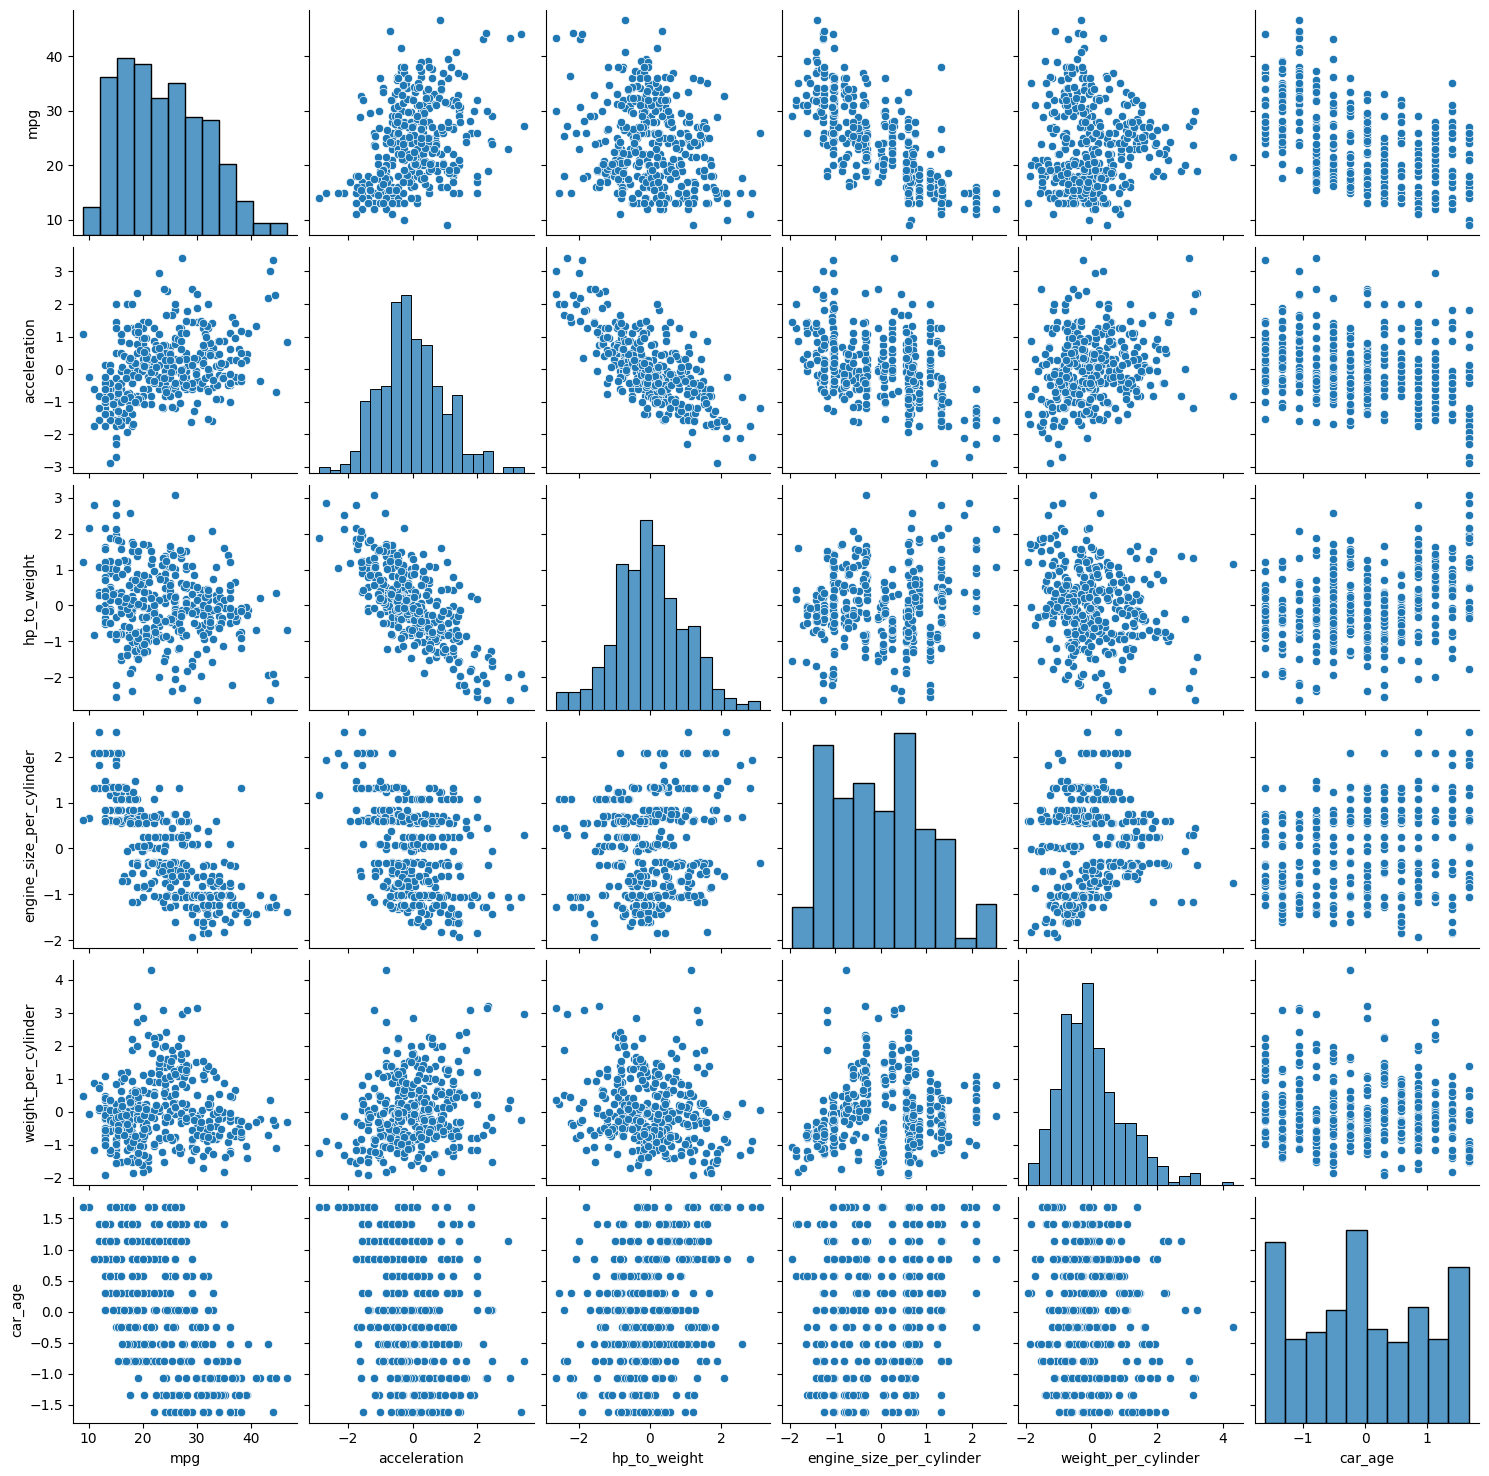

In [121]:
sns.pairplot(df[['mpg', 'acceleration', 'hp_to_weight',  'engine_size_per_cylinder',  'weight_per_cylinder', 'car_age']])

Acceleration và hp_to_weight có phân phối gần với phân phối chuẩn, với một số điểm ngoại lệ ở hai đầu.
Car_age có phân phối không đều và các giá trị xuất hiện ở các điểm rời rạc. Điều này có thể do car_age chứa các giá trị nguyên, thể hiện tuổi của xe theo năm.
hp_to_weight và acceleration có mối quan hệ nghịch, cho thấy rằng khi tỷ lệ mã lực trên khối lượng tăng, gia tốc có xu hướng giảm. .....
ta thấy dữ liêu chạy trong khoảng khá nhỏ là do đã chuẩn hóa làm nổi bật mối quan hệ giữa các biến mà không bị ảnh hưởng bởi sự chênh lệch về thang đo.

                               mpg  acceleration  hp_to_weight  \
mpg                       1.000000      0.391896     -0.208508   
acceleration              0.391896      1.000000     -0.725397   
hp_to_weight             -0.208508     -0.725397      1.000000   
engine_size_per_cylinder -0.769048     -0.414717      0.090697   
weight_per_cylinder      -0.017645      0.224617     -0.213581   
car_age                  -0.561013     -0.247584      0.291985   
origin_japan              0.446219      0.096865      0.125452   
origin_europe             0.234561      0.196922     -0.095595   
origin_usa               -0.555850     -0.235450     -0.029273   

                          engine_size_per_cylinder  weight_per_cylinder  \
mpg                                      -0.769048            -0.017645   
acceleration                             -0.414717             0.224617   
hp_to_weight                              0.090697            -0.213581   
engine_size_per_cylinder               

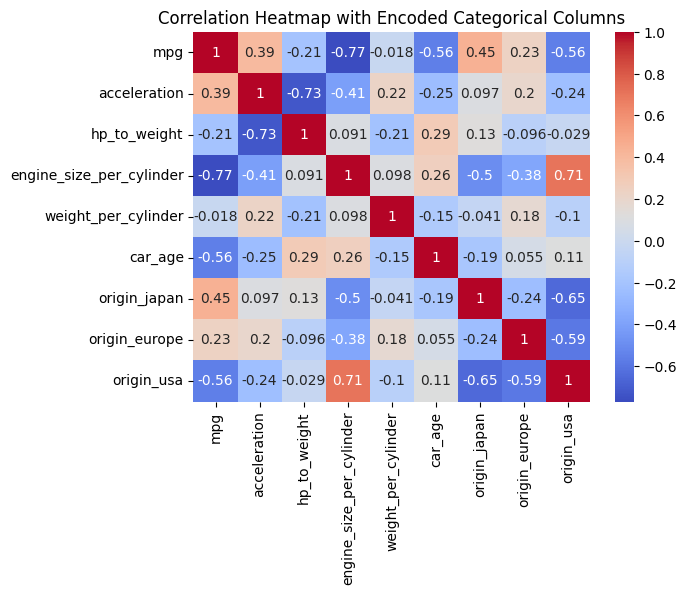

In [122]:
# Tính ma trận tương quan 
corr_matrix = df[['mpg' ,'acceleration', 'hp_to_weight',  'engine_size_per_cylinder',  'weight_per_cylinder', 'car_age' , 'origin_japan', 'origin_europe', 'origin_usa' ]].corr(method='pearson')
print(corr_matrix)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap with Encoded Categorical Columns')
plt.show()


engine_size_per_cylinder có mối tương quan âm mạnh với mpg (-0.769), cho thấy rằng xe có dung tích động cơ trên mỗi xi-lanh lớn hơn thường tiêu thụ nhiều nhiên liệu hơn (tức là mpg thấp hơn).
car_age cũng có mối tương quan âm khá mạnh với mpg (-0.561), gợi ý rằng những xe cũ hơn có xu hướng tiêu thụ nhiên liệu kém hiệu quả hơn.
acceleration và hp_to_weight có mối tương quan âm mạnh (-0.725), cho thấy xe có tỷ lệ mã lực trên trọng lượng cao hơn thì khả năng tăng tốc thấp hơn. Điều này có thể là do xe có công suất lớn thường nặng hơn và không cần phải tăng tốc nhanh như xe nhỏ hơn.


In [123]:
# Phân chia dữ liệu train và test
X = df[['acceleration','hp_to_weight',  'engine_size_per_cylinder',  'weight_per_cylinder', 'car_age' , 'origin_japan', 'origin_europe', 'origin_usa']]
# y là biến phụ thuộc 'mpg'
y = df['mpg']
                        
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Kích thước tập huấn luyện:", X_train.shape[0])
print("Kích thước tập kiểm tra:", X_test.shape[0])
print(X)

Kích thước tập huấn luyện: 305
Kích thước tập kiểm tra: 77
     acceleration  hp_to_weight  engine_size_per_cylinder  \
0       -1.376330      0.511446                  0.666409   
1       -1.564006      1.954812                  1.323445   
2       -1.751683      1.759845                  0.834488   
3       -1.376330      1.767111                  0.620569   
4       -1.939360      1.176315                  0.590010   
..            ...           ...                       ...   
393     -0.025056     -0.683841                  0.253852   
394      3.353127     -1.904867                 -1.060220   
395     -1.526471      0.416382                  0.101053   
396      1.101005     -0.822706                 -0.357344   
397      1.401288     -0.812837                 -0.387904   

     weight_per_cylinder   car_age  origin_japan  origin_europe  origin_usa  
0              -1.410704  1.680954             0              0           1  
1              -1.122829  1.680954             0    

In [ ]:

import statsmodels.formula.api as smf

# Tạo công thức cho mô hình hồi quy tuyến tính
# Liệt kê các cột trong X_train để sử dụng làm biến độc lập
formula = 'mpg ~ acceleration + hp_to_weight + engine_size_per_cylinder + weight_per_cylinder + car_age + origin_japan + origin_europe + origin_usa'

# Kết hợp X_train và y_train thành một DataFrame duy nhất
train_data = pd.concat([X_train, y_train], axis=1)

# Xây dựng mô hình hồi quy tuyến tính
model = smf.ols(formula=formula, data=train_data).fit()

# In kết quả tóm tắt mô hình
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.728
Model:                            OLS   Adj. R-squared:                  0.721
Method:                 Least Squares   F-statistic:                     113.4
Date:                Thu, 09 Jul 2026   Prob (F-statistic):           4.57e-80
Time:                        18:39:44   Log-Likelihood:                -853.83
No. Observations:                 305   AIC:                             1724.
Df Residuals:                     297   BIC:                             1753.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

R-squared = 0.728: Mô hình giải thích khoảng 72.8% sự biến động của biến mục tiêu mpg. Đây là một chỉ số khá tốt, cho thấy mô hình có thể mô phỏng dữ liệu khá chính xác.

coef = 17.9090: là khi các biến đọc lập bằng 0 
coef = -0.3350:
Giá trị âm có nghĩa là nếu tăng tốc tăng lên, mức tiêu thụ nhiên liệu sẽ giảm.
....


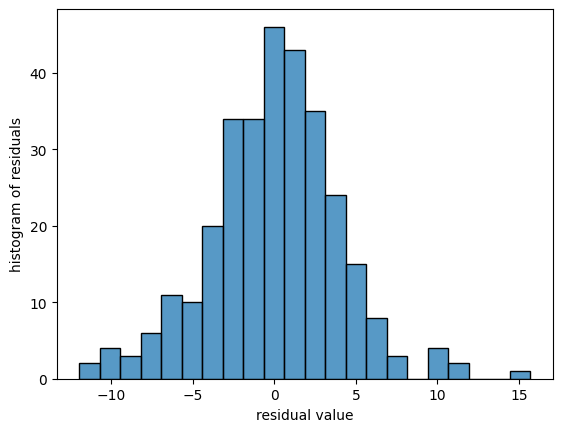

In [125]:
# ta xem phân bố phần dư
residuals = model.resid
# hiển thị biểu đồ histogram
fig = sns.histplot(residuals) 
fig.set_xlabel("residual value")
fig.set_ylabel("histogram of residuals")
plt.show()

Phân phối gần chuẩn: Histogram cho thấy phần dư có xu hướng phân bố xung quanh giá trị 0 và có dạng gần đối xứng. Điều này cho thấy rằng phần dư có thể gần với phân phối chuẩn . 

chủ yếu từ -5 5 

In [126]:
# Xem tỉ lệ phần dư so với khoảng giá trị
train_data["mpg"].describe()

count    305.000000
mean      24.057377
std        7.635152
min       10.000000
25%       18.000000
50%       23.800000
75%       29.900000
max       46.600000
Name: mpg, dtype: float64

ta thấy khoảng giá trị của cột dữ liệu sẽ là 36 mà sai số đang khoảng +-5 chiếm khoảng 27.3% là cũng chấp nhận được

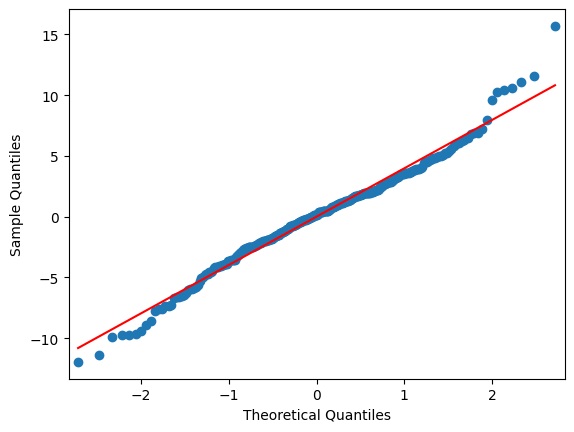

In [127]:
# Kiểm tra tính chuẩn tắc 
fig =sm.qqplot(model.resid, line = "s")
plt.show()

Hầu hết các điểm dữ liệu nằm gần đường chéo màu đỏ, cho thấy rằng phần dư của mô hình có phân phối gần với phân phối chuẩn. 
Hai đầu của đồ thị (các giá trị rất thấp hoặc rất cao của phần dư), một số điểm lệch khỏi đường chéo đỏ. Điều này chỉ ra rằng có một số điểm phần dư xa hơn so với những gì phân phối chuẩn dự đoán, hay còn gọi là outliers.
Ở giữa đồ thị, các điểm dữ liệu gần như nằm sát trên đường thẳng, thể hiện tính chuẩn tắc của phần dư ở phần lớn các giá trị.

177    24.948821
333    30.805299
231    13.627013
104    10.881693
243    28.786021
         ...    
79     25.300189
117    30.617732
282    24.508116
363    24.301456
112    21.639771
Length: 305, dtype: float64


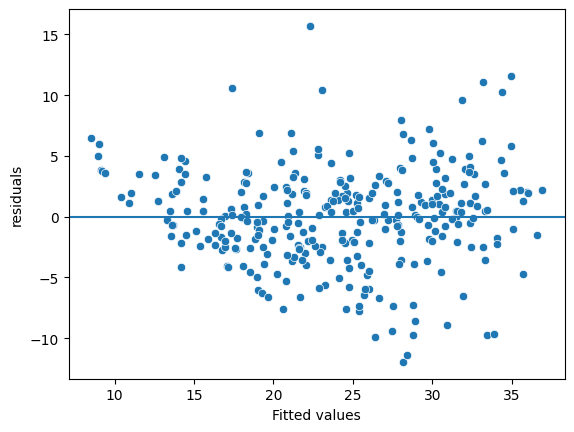

In [128]:
# kiểm tra tính đồng nhất 
fitted_values = model.predict(X_train)
print(fitted_values)
fig = sns.scatterplot(x=fitted_values,y = residuals)
fig.axhline()
fig.set_xlabel("Fitted values")
fig.set_ylabel("residuals")
plt.show()

Trạng thái đồng nhất: Quan sát phần dư có vẻ như phân tán xung quanh trục 0 mà không có mẫu hình cụ thể nào (như hình chữ U hay đường cong). Điều này cho thấy rằng mô hình có thể không có hiện tượng phương sai không đồng nhất . (phương sai không đổi)

In [129]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Dự đoán trên tập kiểm tra
y_pred = model.predict(X_test)

# Tính MAE, MSE, RMSE
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')


MAE: 3.024425193278744
MSE: 14.782495211921955
RMSE: 3.844801062723786


MAE = 3.02
Điều này có nghĩa là trung bình sai số, dự đoán sai lệch khoảng 3.02 đơn vị so với giá trị thực tế. Điều này là tốt vì mpg min là 10 max 46.6 , chiểm khoảng 7%
Giá trị MSE = 14.78
Chỉ số này phản ánh tổng sai số bình phương trung bình. MSE có nhược điểm là nhấn mạnh các sai số lớn hơn vì nó bình phương các sai số. 
Giá trị RMSE =  3.84
RMSE là căn bậc hai của MSE nghĩa là mô hình dự đoán sai trung bình khoảng  3.84 mpg.

#### Kết luận cho người tiêu dùng khi mua xe
1. Nếu bạn đang cân nhắc việc mua một chiếc xe và muốn dự đoán hiệu suất nhiên liệu (mpg), mô hình hồi quy này đã xây dựng có thể là một công cụ hữu ích để tham khảo. Tuy nhiên, có một số điểm quan trọng mà bạn nên ghi nhớ:
Mô hình này giúp  có được một cái nhìn tổng quan về cách các yếu tố như trọng lượng (weight), và năm sản xuất (model year) ảnh hưởng đến hiệu suất nhiên liệu. Tuy nhiên, nó chỉ mang tính chất tham khảo và không thể thay thế cho các yếu tố khác mà bạn nên xem xét khi mua xe.
2. Thực tế thị trường:
Các yếu tố thực tế như tình trạng xe, thương hiệu, bảo trì, và các yếu tố môi trường cũng có ảnh hưởng lớn đến hiệu suất nhiên liệu. Những yếu tố này không được xem xét trong mô hình, nhưng lại rất quan trọng trong quyết định mua sắm của bạn.
##### Kết luận cho Nhà sản xuất ô tô : 
Tối ưu hóa sản phẩm: Các nhà sản xuất ô tô có thể sử dụng mô hình để hiểu rõ hơn về mối quan hệ giữa các yếu tố như trọng lượng (weight), và hiệu suất nhiên liệu (mpg). Điều này giúp họ thiết kế các dòng xe tiết kiệm nhiên liệu hơn, đáp ứng nhu cầu của thị trường.


Ví dụ: Nếu có một xe sản xuất năm 2015, từ Nhật Bản, có giá trị tăng tốc là 10, và trọng lượng 3000 pound,  sẽ tính như sau:

model_year = 2015
origin_japan = 1 (do xe này từ Nhật Bản)
origin_europe = 0
origin_usa = 0
acceleration = 10
weight = 3000
hp_to_weight: Tỷ lệ giữa công suất động cơ (horsepower) và trọng lượng xe (weight).
engine_size_per_cylinder: Kích thước động cơ trên mỗi xi lanh (displacement/cylinders).
weight_per_cylinder: Trọng lượng xe trên mỗi xi lanh (weight/cylinders).
car_age: Tuổi của xe (current_year - model_year).

hp_to_weight = 150 / 3000 = 0.05
engine_size_per_cylinder = 200 / 4 = 50
weight_per_cylinder = 3000 / 4 = 750
car_age = 2024 - 2015 = 9


mpg =   41 dặm / mlgalon nhiên liệu
<!-- sai số 7 phần trăm  -->